# CMS General Payments EDA

## Research Questions
1. **Are there unusual outliers of providers receiving payments from companies?**
2. **Are higher manufacturer payments indicative of higher claims reimbursements?**

## Key Investigation Areas
- Nature of Payments Analysis
- Provider Outlier Detection
- Kickback Pattern Detection
- Geographic and Specialty Risk Profiling
- Fraud Flagged Investigators

In [2]:
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================
import pandas as pd
from matplotlib.ticker import FuncFormatter
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

# =============================================================================
# 1. COLORBLIND-FRIENDLY PALETTE  (Wong 2011, Nature Methods)
#    These 8 colors are maximally distinguishable for all color vision types.
# =============================================================================
CB_PALETTE = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#CC79A7",  # pink
    "#56B4E9",  # sky blue
    "#D55E00",  # vermillion
    "#F0E442",  # yellow
    "#000000",  # black
]

# =============================================================================
# 2. FONT DETECTION & SETTINGS
#    Auto-picks the best sans-serif font already on your machine.
#    Minimum size is 18pt; titles and labels are larger.
#
#    >>> To see ALL fonts available on your system, run in a cell:
#    >>>     from plot_template import list_fonts
#    >>>     list_fonts()
#
#    >>> To override the auto-picked font, set FONT_FAMILY before importing:
#    >>>     import plot_template
#    >>>     plot_template.FONT_FAMILY = "Verdana"
#    >>>     plot_template.apply_style()   # re-apply with your choice
# =============================================================================

def list_fonts(filter_text=None):
    """
    Print every font matplotlib can see on your system.
    Pass a string to filter, e.g. list_fonts("arial") or list_fonts("sans").
    """
    names = sorted({f.name for f in fm.fontManager.ttflist})
    if filter_text:
        names = [n for n in names if filter_text.lower() in n.lower()]
    print(f"Found {len(names)} font{'s' if len(names) != 1 else ''}:\n")
    for n in names:
        print(f"  • {n}")
    return names

# Preferred fonts in priority order (all clean presentation sans-serifs)
_FONT_PREFERENCES = [
    "Arial",
    "Helvetica",
    "Helvetica Neue",
    "Calibri",
    "Verdana",
    "Segoe UI",
    "Liberation Sans",
    "DejaVu Sans",
]

def _find_best_font():
    """Return the first preferred font that is actually installed."""
    available = {f.name for f in fm.fontManager.ttflist}
    for font in _FONT_PREFERENCES:
        if font in available:
            return font
    # Nothing from the preferred list — just grab any sans-serif we can find
    for name in sorted(available):
        if "sans" in name.lower():
            return name
    # True last resort
    return "DejaVu Sans"

FONT_FAMILY = _find_best_font()
print(f"Font: {FONT_FAMILY}")
FONT_SIZE_TITLE   = 30      # figure / axes title
FONT_SIZE_LABEL   = 24      # axis labels
FONT_SIZE_TICK    = 20      # tick labels
FONT_SIZE_LEGEND  = 20      # legend text
FONT_SIZE_ANNOT   = 20      # annotations / text on plot

# =============================================================================
# 3. APPLY GLOBAL STYLE (matplotlib + seaborn)
#    Called automatically on import. Call again after changing FONT_FAMILY.
# =============================================================================

def apply_style():
    """Apply (or re-apply) the full presentation style using current settings."""
    mpl.rcParams.update({
        # --- Font -----------------------------------------------------------
        "font.family":        "sans-serif",
        "font.sans-serif":    [FONT_FAMILY, "Helvetica", "DejaVu Sans"],
        "font.size":          FONT_SIZE_ANNOT,       # base / fallback size

        # --- Axes -----------------------------------------------------------
        "axes.titlesize":     FONT_SIZE_TITLE,
        "axes.titleweight":   "bold",
        "axes.labelsize":     FONT_SIZE_LABEL,
        "axes.labelweight":   "bold",
        "axes.prop_cycle":    mpl.cycler(color=CB_PALETTE),
        "axes.linewidth":     1.5,
        "axes.edgecolor":     "#000000",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "axes.grid":          True,
        "axes.axisbelow":     True,                   # grid behind data

        # --- Ticks ----------------------------------------------------------
        "xtick.labelsize":    FONT_SIZE_TICK,
        "ytick.labelsize":    FONT_SIZE_TICK,
        "xtick.major.width":  1.5,
        "ytick.major.width":  1.5,
        "xtick.major.size":   6,
        "ytick.major.size":   6,
        "xtick.direction":    "out",
        "ytick.direction":    "out",

        # --- Grid -----------------------------------------------------------
        "grid.color":         "#dbdbdb",
        "grid.linewidth":     0.8,
        "grid.alpha":         1.0,

        # --- Legend ----------------------------------------------------------
        "legend.fontsize":    FONT_SIZE_LEGEND,
        "legend.frameon":     True,
        "legend.framealpha":  0.9,
        "legend.edgecolor":   "#999999",
        "legend.fancybox":    True,
        "legend.shadow":      False,
        "legend.loc":         "best",

        # --- Lines & markers ------------------------------------------------
        "lines.linewidth":    2.5,
        "lines.markersize":   10,

        # --- Figure ---------------------------------------------------------
        "figure.figsize":     (12, 7),
        "figure.dpi":         100,
        "figure.facecolor":   "white",
        "figure.titlesize":   FONT_SIZE_TITLE,
        "figure.titleweight": "bold",

        # --- Saving ---------------------------------------------------------
        "savefig.dpi":        300,
        "savefig.bbox":       "tight",
        "savefig.facecolor":  "white",
    })

    sns.set_theme(
        style="whitegrid",
        font=FONT_FAMILY,
        font_scale=1.4,
        rc=mpl.rcParams,
    )
    sns.set_palette(CB_PALETTE)

    # Re-assert settings that seaborn's set_theme can override
    mpl.rcParams.update({
        "axes.titlesize":     FONT_SIZE_TITLE,
        "axes.titleweight":   "bold",
        "axes.labelweight":   "bold",
        "axes.edgecolor":     "#000000",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "figure.titlesize":   FONT_SIZE_TITLE,
        "figure.titleweight": "bold",
        "grid.color":         "#dbdbdb",
        "grid.alpha":         1.0,
    })

# Auto-apply on import
apply_style()

# =============================================================================
# 5. HELPER FUNCTIONS
# =============================================================================

def add_legend(ax=None, title=None, **kwargs):
    """
    Add a styled legend to the current or specified axes.
    Merges template defaults with any overrides you pass in.
    """
    ax = ax or plt.gca()
    defaults = dict(
        fontsize=FONT_SIZE_LEGEND,
        frameon=True,
        framealpha=0.9,
        edgecolor="#999999",
        loc="best",
    )
    defaults.update(kwargs)
    legend = ax.legend(title=title, **defaults)
    if title:
        legend.get_title().set_fontsize(FONT_SIZE_LEGEND)
        legend.get_title().set_fontweight("bold")
    return legend


def get_colors(n=None):
    """
    Return the colorblind-friendly palette (or the first n colors).
    Useful when you need explicit color assignments.

    Usage:
        colors = get_colors(3)
        ax.bar(x, y1, color=colors[0], label="Group A")
        ax.bar(x, y2, color=colors[1], label="Group B")
    """
    if n is None:
        return CB_PALETTE.copy()
    return CB_PALETTE[:n]


def finalize(fig=None, tight=True):
    """
    Call at the end of every plot cell to tighten layout.
    """
    fig = fig or plt.gcf()
    if tight:
        fig.tight_layout()


Font: Liberation Sans


In [3]:
# =============================================================================
# DATA LOADING
# =============================================================================
df = pd.read_csv("/dsa/groups/casestudycf25/team02/cms_general_payments_clean.csv", dtype=str)
print(f'Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory Usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Dataset Shape: 932,908 rows x 68 columns
Memory Usage: 3339.4 MB


In [4]:
temp_df = df[df["recipient_state"].isin(['MO', 'IL', 'IA', 'OK', 'AR', 'TN', 'KS', 'NE', 'KY'])]

In [12]:
# =============================================================================
# DATA LOADING
# =============================================================================
temp_df = df[:30000].copy()
temp_df.to_csv("cms_general_payments_clean_sample.csv")

In [4]:
special_types = {
    "program_year": "Int64",   # Pandas nullable integer
    "number_of_payments_included_in_total_amount": "Int64",
    "covered_recipient_npi": "Int64",
    "total_amount_of_payment_us_dollars": "float64",
    "payment_publication_date": "datetime64[ns]",
    "date_of_payment": "datetime64[ns]",
}

In [5]:
df.columns

Index(['change_type', 'covered_recipient_type', 'covered_recipient_profile_id',
       'covered_recipient_npi',
       'recipient_primary_business_street_address_line1',
       'recipient_primary_business_street_address_line2', 'recipient_city',
       'recipient_state', 'recipient_zip_code', 'recipient_country',
       'recipient_postal_code', 'covered_recipient_primary_type_1',
       'covered_recipient_specialty_1',
       'covered_recipient_license_state_code1',
       'covered_recipient_license_state_code2',
       'covered_recipient_license_state_code3',
       'covered_recipient_license_state_code4',
       'covered_recipient_license_state_code5',
       'applicable_manufacturer_or_applicable_gpo_making_payment_id',
       'applicable_manufacturer_or_applicable_gpo_making_payment_name',
       'applicable_manufacturer_or_applicable_gpo_making_payment_state',
       'applicable_manufacturer_or_applicable_gpo_making_payment_country',
       'total_amount_of_payment_us_dollars', 'd

In [6]:
for col, dtype in special_types.items():
    if dtype == "datetime64[ns]":
        df[col] = pd.to_datetime(df[col], errors = "coerce")

    elif dtype == "Int64":
        df[col] = pd.to_numeric(df[col], errors = "coerce").astype("Int64")

    elif dtype == "float64":
        df[col] = pd.to_numeric(df[col], errors = "coerce")

    else:
        df[col] = df[col].astype(dtype)

In [7]:
#####################
# Drop unrelated columns
#####################
drops_cols = [
    'covered_recipient_first_name', 'covered_recipient_middle_name', #unnecessary to have name
    'teaching_hospital_ccn', 'teaching_hospital_id', 'teaching_hospital_name', #no teaching hospitals
    'covered_recipient_last_name', 'covered_recipient_name_suffix', 
     'recipient_province',
    'covered_recipient_primary_type_2','covered_recipient_primary_type_3', 'covered_recipient_specialty_2', # mostly blank
    'related_product_indicator','delay_in_publication_indicator', #only Nos so remove
     'associated_drug_or_biological_ndc_1', 'associated_drug_or_biological_ndc_2', # remove unrelated drug info
    'associated_drug_or_biological_ndc_3','associated_drug_or_biological_ndc_4', 'associated_drug_or_biological_ndc_5',
    'submitting_applicable_manufacturer_or_applicable_gpo_name' # mostly the same as applicable manufacturer name
]

In [8]:
# =============================================================================
# DATA PREPARATION
# =============================================================================
df['date_of_payment'] = pd.to_datetime(df['date_of_payment'], errors='coerce')
df['payment_month'] = df['date_of_payment'].dt.month
df['payment_quarter'] = df['date_of_payment'].dt.quarter
df['log_amount'] = np.log1p(df['total_amount_of_payment_us_dollars'])
df['mfr_provider_pair'] = (df['applicable_manufacturer_or_applicable_gpo_making_payment_id'].astype(str) + '_' + df['covered_recipient_npi'].astype(str))

# Region mapping
region_map = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest',
    'ND': 'Midwest', 'SD': 'Midwest',
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South',
    'SC': 'South', 'VA': 'South', 'DC': 'South', 'WV': 'South', 'AL': 'South',
    'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South',
    'OK': 'South', 'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West',
    'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West',
    'HI': 'West', 'OR': 'West', 'WA': 'West'
}
df['recipient_region'] = df['recipient_state'].map(region_map)
print('Data preparation complete.')

Data preparation complete.


## Overview Cards

In [9]:
# =============================================================================
# Data Overview
# =============================================================================
total_payments = df['total_amount_of_payment_us_dollars'].sum()
unique_providers = df['covered_recipient_npi'].nunique()
unique_manufacturers = df['applicable_manufacturer_or_applicable_gpo_making_payment_name'].nunique()
unique_pairs = df['mfr_provider_pair'].nunique()

print('=' * 70)
print('DATASET OVERVIEW')
print('=' * 70)
print(f'Total Payment Records: {len(df):,}')
print(f'Total Payment Value: ${total_payments:,.2f}')
print(f'Unique Providers (NPIs): {unique_providers:,}')
print(f'Unique Manufacturers: {unique_manufacturers:,}')

DATASET OVERVIEW
Total Payment Records: 932,908
Total Payment Value: $507,462,113.64
Unique Providers (NPIs): 85,287
Unique Manufacturers: 836


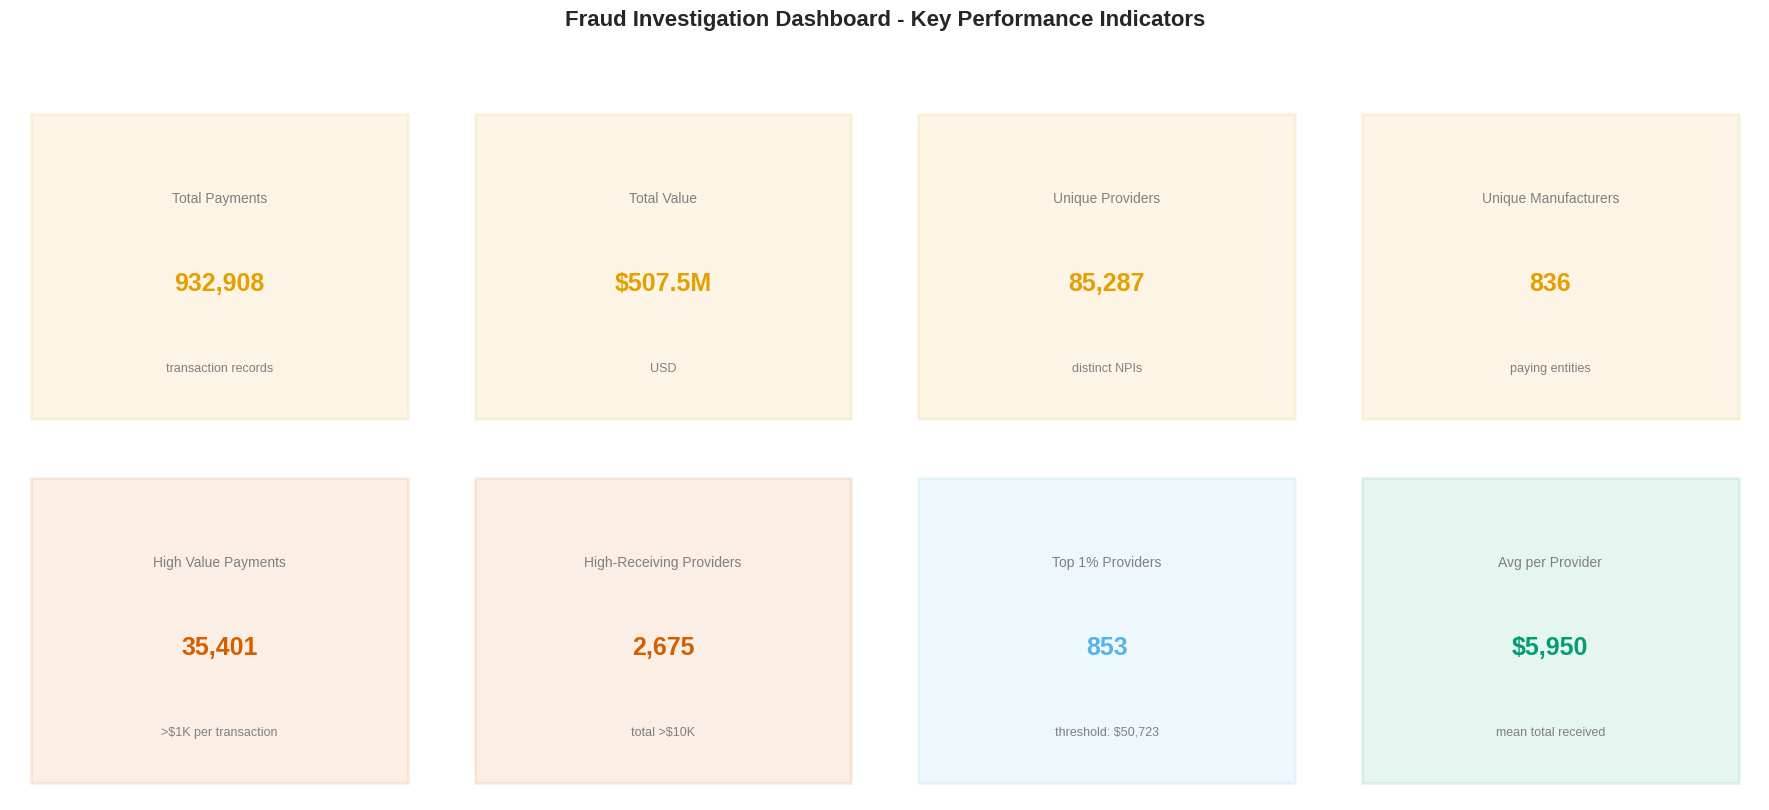

In [10]:
# =============================================================================
# KPI DASHBOARD VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Fraud Investigation Dashboard - Key Performance Indicators', fontsize=16, fontweight='bold', y=1.02)

def draw_kpi(ax, title, value, subtitle='', color=CB_PALETTE[1]):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=True, facecolor=color, alpha=0.1, edgecolor=color, linewidth=2))
    ax.text(0.5, 0.7, title, ha='center', va='center', fontsize=10, color='gray')
    ax.text(0.5, 0.45, value, ha='center', va='center', fontsize=18, fontweight='bold', color=color)
    ax.text(0.5, 0.2, subtitle, ha='center', va='center', fontsize=9, color='gray')

# Row 1
draw_kpi(axes[0,0], 'Total Payments', f'{len(df):,}', 'transaction records')
draw_kpi(axes[0,1], 'Total Value', f'${total_payments/1e6:.1f}M', 'USD')
draw_kpi(axes[0,2], 'Unique Providers', f'{unique_providers:,}', 'distinct NPIs')
draw_kpi(axes[0,3], 'Unique Manufacturers', f'{unique_manufacturers:,}', 'paying entities')

# Risk metrics
high_value_count = (df['total_amount_of_payment_us_dollars'] > 1000).sum()
provider_totals = df.groupby('covered_recipient_npi')['total_amount_of_payment_us_dollars'].sum()
high_receiving = (provider_totals > 10000).sum()
top_1pct_threshold = provider_totals.quantile(0.99)
top_1pct_count = (provider_totals >= top_1pct_threshold).sum()

# Row 2
draw_kpi(axes[1,0], 'High Value Payments', f'{high_value_count:,}', '>$1K per transaction', color=CB_PALETTE[5])
draw_kpi(axes[1,1], 'High-Receiving Providers', f'{high_receiving:,}', 'total >$10K', color=CB_PALETTE[5])
draw_kpi(axes[1,2], 'Top 1% Providers', f'{top_1pct_count:,}', f'threshold: ${top_1pct_threshold:,.0f}', color=CB_PALETTE[4])
draw_kpi(axes[1,3], 'Avg per Provider', f'${provider_totals.mean():,.0f}', 'mean total received', color=CB_PALETTE[2])

plt.tight_layout()
# plt.savefig('dashboard_kpis.png', dpi=150, bbox_inches='tight')
plt.show()


######################################
# COMMENTS FOR UPDATING: 
# Add in % of totals to the captions of each card
# Compare the 1% of payments to the fraud labeled
# Add in fraud label card overviews
######################################


## Research Question 1: Provider Payment Outliers

**Question: Are there unusual outliers of providers receiving payments from companies?**

In [11]:
# =============================================================================
# PROVIDER-LEVEL AGGREGATION
# =============================================================================
provider_stats = df.groupby('covered_recipient_npi').agg({
    'total_amount_of_payment_us_dollars': ['count', 'sum', 'mean', 'median', 'max'],
    'applicable_manufacturer_or_applicable_gpo_making_payment_name': 'nunique',
    'nature_short_descr': lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'Unknown',
    'specialty_lvl1': 'first',
    'recipient_state': 'first'
}).reset_index()

provider_stats.columns = ['npi', 'payment_count', 'total_received', 'mean_payment', 
                          'median_payment', 'max_payment', 'num_manufacturers',
                          'primary_nature', 'specialty', 'state']

# Calculate z-scores for outlier detection
provider_stats['zscore_total'] = stats.zscore(np.log1p(provider_stats['total_received']))
provider_stats['zscore_count'] = stats.zscore(np.log1p(provider_stats['payment_count']))

# Flag outliers (z-score > 3)
provider_stats['is_outlier_total'] = provider_stats['zscore_total'] > 3
provider_stats['is_outlier_count'] = provider_stats['zscore_count'] > 3
provider_stats['is_outlier_any'] = provider_stats['is_outlier_total'] | provider_stats['is_outlier_count']

print('PROVIDER-LEVEL OUTLIER SUMMARY')
print('=' * 70)
print(f'Total unique providers: {len(provider_stats):,}')
print(f'Outliers by total received (z>3): {provider_stats["is_outlier_total"].sum():,}')
print(f'Outliers by payment count (z>3): {provider_stats["is_outlier_count"].sum():,}')
print(f'Outliers by either metric: {provider_stats["is_outlier_any"].sum():,}')

PROVIDER-LEVEL OUTLIER SUMMARY
Total unique providers: 85,287
Outliers by total received (z>3): 936
Outliers by payment count (z>3): 664
Outliers by either metric: 1,281


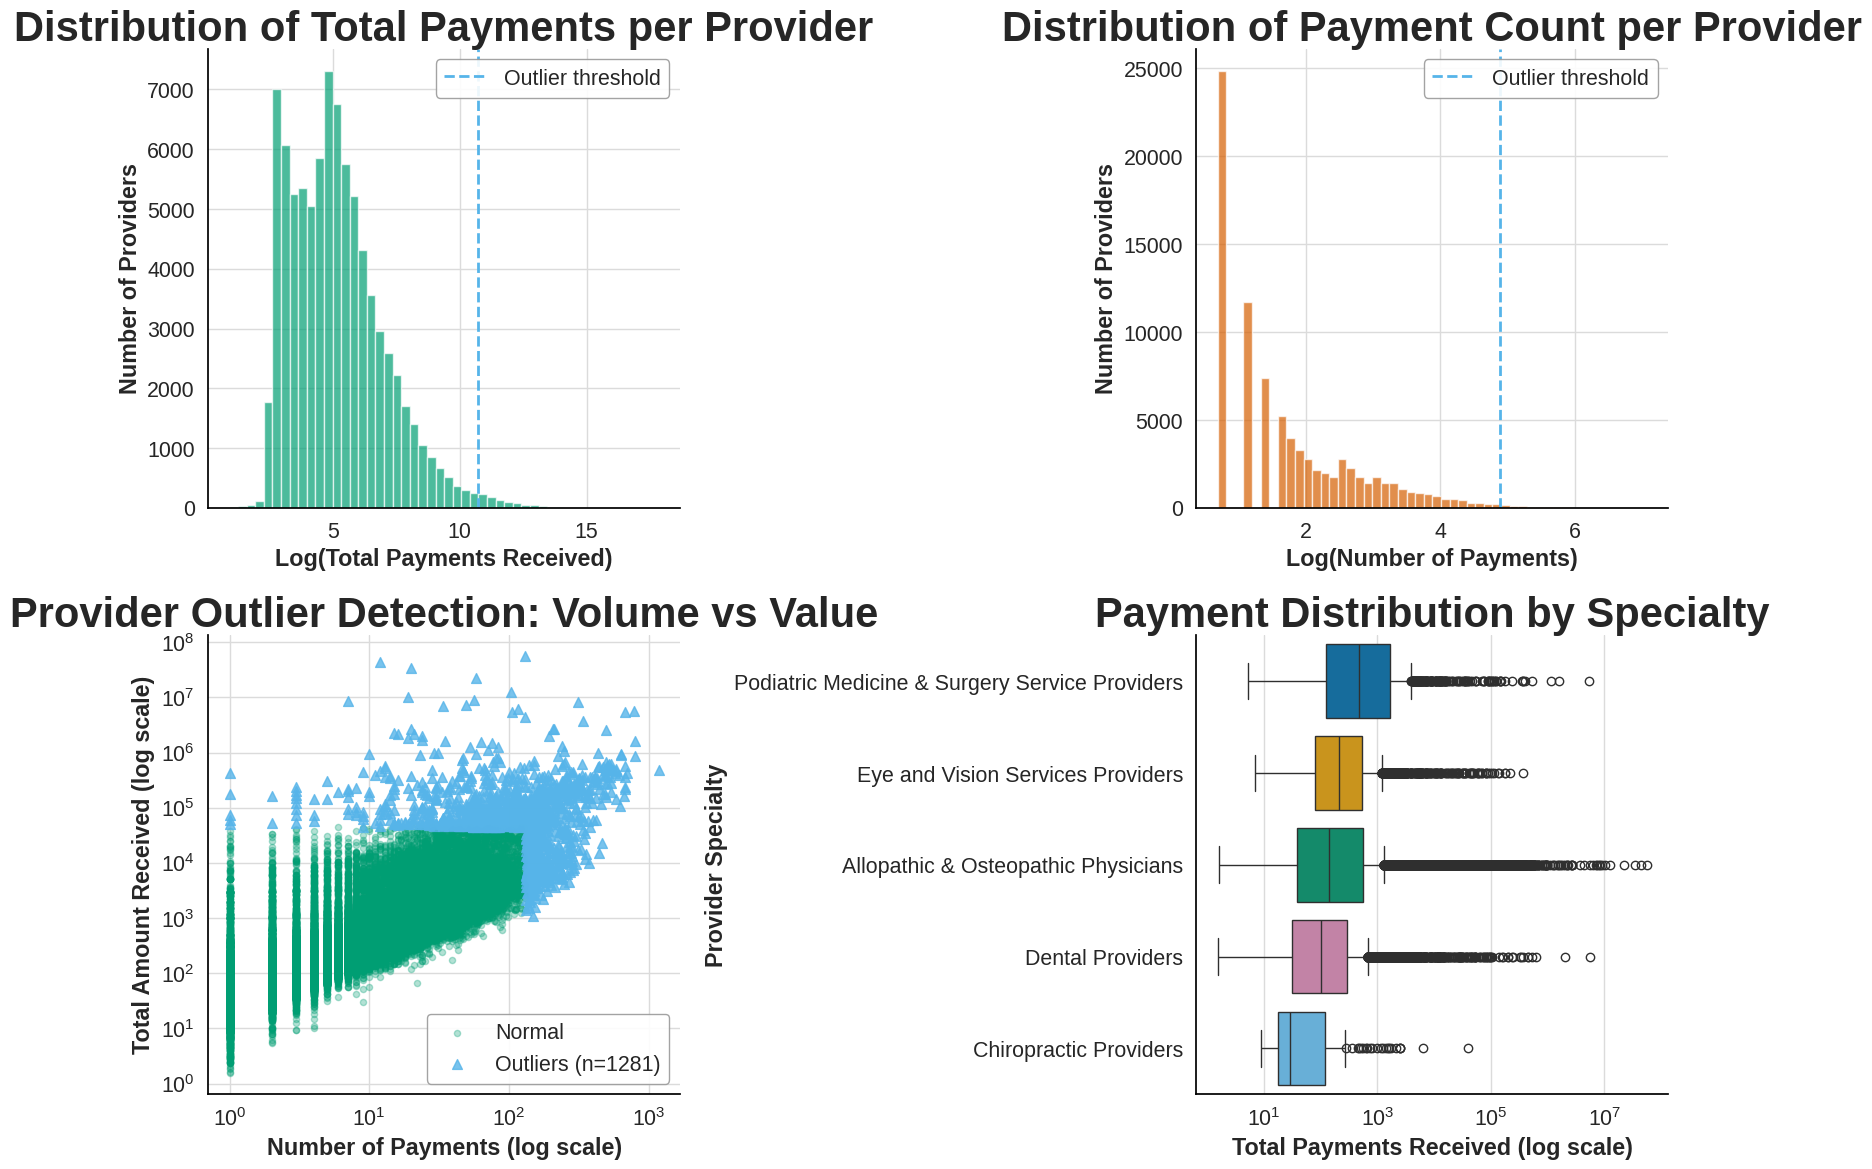

In [12]:
# =============================================================================
# PROVIDER OUTLIER SCATTER PLOT
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: Distribution of total payments per provider
ax1 = axes[0, 0]
ax1.hist(np.log1p(provider_stats['total_received']), bins=50, color=CB_PALETTE[2], edgecolor='white', alpha=0.7)
if provider_stats['is_outlier_total'].any():
    threshold = np.log1p(provider_stats[provider_stats['is_outlier_total']]['total_received'].min())
    ax1.axvline(threshold, color=CB_PALETTE[4], linestyle='--', linewidth=2, label='Outlier threshold')
ax1.set_xlabel('Log(Total Payments Received)')
ax1.set_ylabel('Number of Providers')
ax1.set_title('Distribution of Total Payments per Provider', fontweight='bold')
ax1.legend()

# Top-right: Distribution of payment count
ax2 = axes[0, 1]
ax2.hist(np.log1p(provider_stats['payment_count']), bins=50, color=CB_PALETTE[5], edgecolor='white', alpha=0.7)
if provider_stats['is_outlier_count'].any():
    threshold = np.log1p(provider_stats[provider_stats['is_outlier_count']]['payment_count'].min())
    ax2.axvline(threshold, color=CB_PALETTE[4], linestyle='--', linewidth=2, label='Outlier threshold')
ax2.set_xlabel('Log(Number of Payments)')
ax2.set_ylabel('Number of Providers')
ax2.set_title('Distribution of Payment Count per Provider', fontweight='bold')
ax2.legend()

# Bottom-left: Scatter - count vs total
ax3 = axes[1, 0]
non_outliers = provider_stats[~provider_stats['is_outlier_any']]
outliers = provider_stats[provider_stats['is_outlier_any']]
ax3.scatter(non_outliers['payment_count'], non_outliers['total_received'], alpha=0.3, s=20, c=CB_PALETTE[2], label='Normal')
ax3.scatter(outliers['payment_count'], outliers['total_received'], alpha=0.8, s=50, c=CB_PALETTE[4], marker='^', label=f'Outliers (n={len(outliers)})')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel('Number of Payments (log scale)')
ax3.set_ylabel('Total Amount Received (log scale)')
ax3.set_title('Provider Outlier Detection: Volume vs Value', fontweight='bold')
ax3.legend()

# Bottom-right: Boxplot by specialty
ax4 = axes[1, 1]
top_specs = provider_stats['specialty'].value_counts().head(8).index
spec_data = provider_stats[provider_stats['specialty'].isin(top_specs)]
order = spec_data.groupby('specialty')['total_received'].median().sort_values(ascending=False).index
sns.boxplot(data=spec_data, y='specialty', x='total_received', order=order, ax=ax4, palette=CB_PALETTE)
ax4.set_xscale('log')
ax4.set_xlabel('Total Payments Received (log scale)')
ax4.set_ylabel('Provider Specialty')
ax4.set_title('Payment Distribution by Specialty', fontweight='bold')

plt.tight_layout()
# plt.savefig('provider_outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

######################################
# COMMENTS FOR UPDATING: 
# Do not add outlier visuals to dashboard given the unsupervised
# KEEP adjusted box and whisker.
######################################

In [13]:
# =============================================================================
# TOP OUTLIER PROVIDERS TABLE
# =============================================================================
top_outliers = provider_stats.nlargest(25, 'total_received')[[
    'npi', 'specialty', 'state', 'payment_count', 'total_received', 
    'mean_payment', 'num_manufacturers', 'primary_nature', 'zscore_total'
]].copy()
top_outliers.columns = ['NPI', 'Specialty', 'State', 'Count', 'Total', 'Avg', 'Num Mfrs', 'Nature', 'Z-Score']

print('TOP 25 PROVIDERS BY TOTAL PAYMENTS RECEIVED')
print('=' * 100)
print(top_outliers.to_string(index=False))

TOP 25 PROVIDERS BY TOTAL PAYMENTS RECEIVED
       NPI                                      Specialty State  Count         Total          Avg  Num Mfrs            Nature  Z-Score
1861451874            Allopathic & Osteopathic Physicians    TN    130 56,094,047.03   431,492.67         5 Food and Beverage     6.85
1336247469            Allopathic & Osteopathic Physicians    KS     12 43,366,542.57 3,613,878.55         1           Unknown     6.71
1295737930            Allopathic & Osteopathic Physicians    TN     20 33,852,863.72 1,692,643.19         3 Food and Beverage     6.58
1811044548            Allopathic & Osteopathic Physicians    MO     58 22,318,074.80   384,794.39         6 Food and Beverage     6.35
1629021571            Allopathic & Osteopathic Physicians    IL    104 12,591,925.95   121,076.21         2 Food and Beverage     6.05
1275512964            Allopathic & Osteopathic Physicians    IL     19 10,107,470.58   531,972.14         1           Unknown     5.93
1154316636 

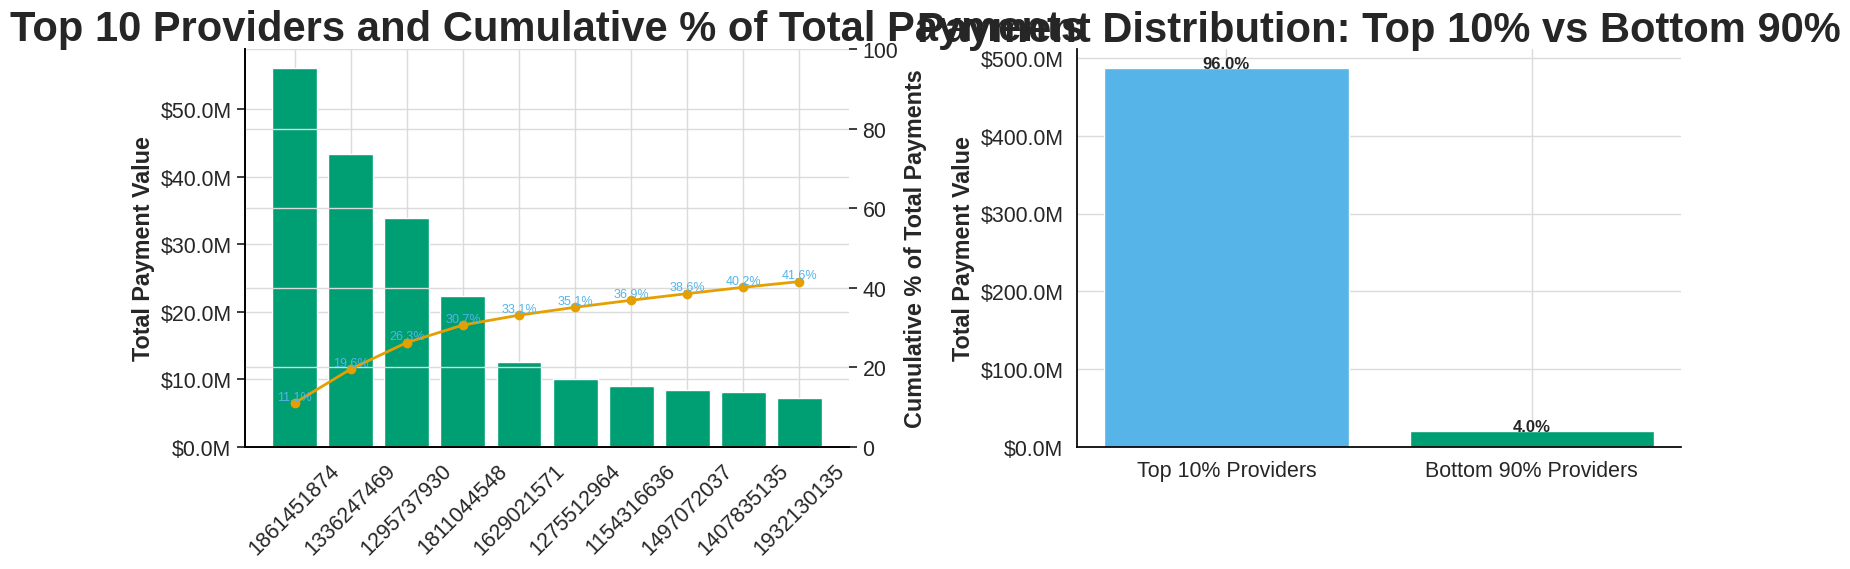


PAYMENT CONCENTRATION STATISTICS
Top 1% of providers receive: 83.4% of all payments
Top 5% of providers receive: 93.3% of all payments
Top 10% of providers receive: 96.0% of all payments


In [14]:
# =============================================================================
# PARETO ANALYSIS - PAYMENT CONCENTRATION
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------------------
# Left: Top 10 Providers + Cumulative % Line
# -------------------------------------------------------------------------
ax1 = axes[0]

# Sort providers by total received
sorted_provs = provider_stats.sort_values('total_received', ascending=False).reset_index(drop=True)

# Compute cumulative % relative to ALL payments
total_all = sorted_provs['total_received'].sum()
sorted_provs['cumulative_pct_total'] = sorted_provs['total_received'].cumsum() / total_all * 100

# Select top 10 providers
top10 = sorted_provs.head(10).copy()
top10['rank'] = top10.index + 1

# Build labels dynamically
if 'npi' in top10.columns:
    x_labels = top10['npi'].astype(str).tolist()
else:
    x_labels = [f'Provider {i}' for i in top10['rank']]

# Bar chart for payment totals
bars = ax1.bar(
    x_labels,
    top10['total_received'],
    color=CB_PALETTE[2],
    edgecolor='white'
)

# Format left axis
ax1.set_ylabel('Total Payment Value')
ax1.set_title('Top 10 Providers and Cumulative % of Total Payments', fontweight='bold')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax1.tick_params(axis='x', rotation=45)

# Secondary axis for cumulative percentage
ax1b = ax1.twinx()

ax1b.plot(
    x_labels,
    top10['cumulative_pct_total'],
    color=CB_PALETTE[1],
    marker='o',
    linewidth=2
)

ax1b.set_ylabel('Cumulative % of Total Payments')
ax1b.set_ylim(0, max(100, float(top10['cumulative_pct_total'].max()) * 1.05))

# Annotate cumulative % values
for x, pct in zip(x_labels, top10['cumulative_pct_total']):
    ax1b.text(
        x,
        pct,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        color=CB_PALETTE[4]
    )

# -------------------------------------------------------------------------
# Right: Top 10% vs Bottom 90% (UNCHANGED)
# -------------------------------------------------------------------------
ax2 = axes[1]

top_10_n = int(len(provider_stats) * 0.1)
top_10 = provider_stats.nlargest(top_10_n, 'total_received')
bottom_90 = provider_stats.nsmallest(len(provider_stats) - top_10_n, 'total_received')

values = [top_10['total_received'].sum(), bottom_90['total_received'].sum()]
labels = ['Top 10% Providers', 'Bottom 90% Providers']
colors_bar = [CB_PALETTE[4], CB_PALETTE[2]]

bars = ax2.bar(labels, values, color=colors_bar, edgecolor='white')

ax2.set_ylabel('Total Payment Value')
ax2.set_title('Payment Distribution: Top 10% vs Bottom 90%', fontweight='bold')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

for bar, val in zip(bars, values):
    pct = val / sum(values) * 100
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
# plt.savefig('payment_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPAYMENT CONCENTRATION STATISTICS')
print('=' * 70)
for pct_thresh in [1, 5, 10]:
    val = sorted_provs[(sorted_provs.index + 1) / len(sorted_provs) * 100 <= pct_thresh]['total_received'].sum() / total_all * 100
    print(f'Top {pct_thresh}% of providers receive: {val:.1f}% of all payments')

######################################
# COMMENTS FOR UPDATING: 
# Legend of the specialties of the top providers
# Or legend color by the nature of payment
######################################

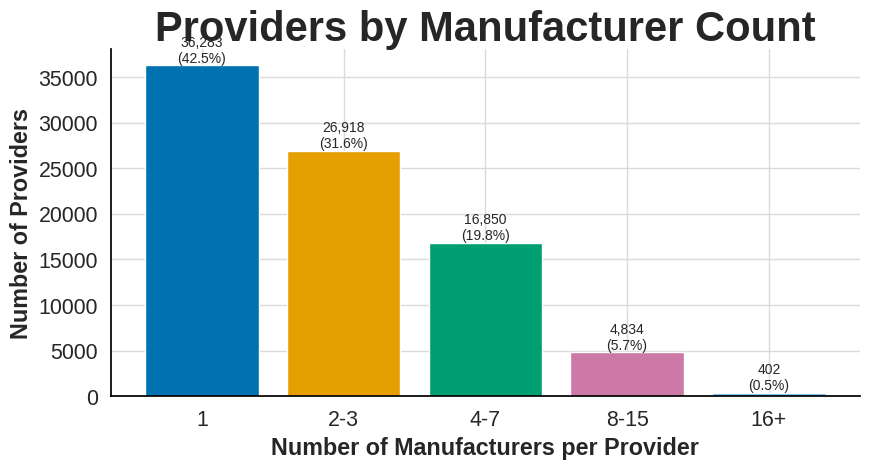

In [17]:
# =============================================================================
# DYNAMICALLY BUCKETED PROVIDERS BY MANUFACTURER COUNT
# =============================================================================

# Aggregate payments at provider-manufacturer level; removes duplicate rows per pair
provider_mfr = df.groupby(
    ['covered_recipient_npi', 'applicable_manufacturer_or_applicable_gpo_making_payment_name']
)['total_amount_of_payment_us_dollars'].sum().reset_index()

# Rename columns for clarity during grouping
provider_mfr.columns = ['npi', 'manufacturer', 'amount']

# Count distinct manufacturers per provider; measures diversification breadth
mfr_counts = provider_mfr.groupby('npi')['manufacturer'].nunique().reset_index()

# Rename resulting column to reflect meaning
mfr_counts.columns = ['npi', 'manufacturer_count']

# Determine the maximum manufacturer count observed; drives dynamic bucket creation
max_count = int(mfr_counts['manufacturer_count'].max())

# Create bucket edges dynamically; first bucket is 1, then ranges expand by powers of two
bins = [0, 1]
step = 2

# Grow bin edges until covering the observed maximum
while bins[-1] < max_count:
    bins.append(bins[-1] + step)
    step *= 2

# Ensure final bin captures all remaining values
if bins[-1] < max_count:
    bins.append(float('inf'))
else:
    bins[-1] = float('inf')

# Build readable labels from bin edges
labels = []
for low, high in zip(bins[:-1], bins[1:]):
    if high == float('inf'):
        labels.append(f'{int(low+1)}+')
    elif high - low == 1:
        labels.append(f'{int(high)}')
    else:
        labels.append(f'{int(low+1)}-{int(high)}')

# Assign providers into dynamic manufacturer-count buckets
mfr_counts['mfr_group'] = pd.cut(
    mfr_counts['manufacturer_count'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# Count providers per bucket and preserve bucket order
group_counts = mfr_counts['mfr_group'].value_counts().reindex(labels).fillna(0)

# Convert COLORS dict into a reusable ordered list
color_list = CB_PALETTE

# Assign a different color to each bar; cycles if buckets exceed palette length
bar_colors = [color_list[i % len(color_list)] for i in range(len(group_counts))]

# Create figure for single visual
fig, ax = plt.subplots(figsize=(9, 5))

# Plot dynamically bucketed distribution
bars = ax.bar(group_counts.index.astype(str), group_counts.values, color=bar_colors, edgecolor='white')

# Label axes for interpretation
ax.set_xlabel('Number of Manufacturers per Provider')

# Label metric being counted
ax.set_ylabel('Number of Providers')

# Add descriptive title
ax.set_title('Providers by Manufacturer Count', fontweight='bold')

# Compute total providers for percentage annotation
total_providers = int(group_counts.sum())

# Annotate bars with counts and percentages
for bar, count in zip(bars, group_counts.values):
    pct = (count / total_providers * 100) if total_providers else 0
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(count):,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Prevent clipping
plt.tight_layout()

# Save output image
# plt.savefig('providers_dynamic_manufacturer_buckets.png', dpi=150, bbox_inches='tight')

# Display chart
plt.show()

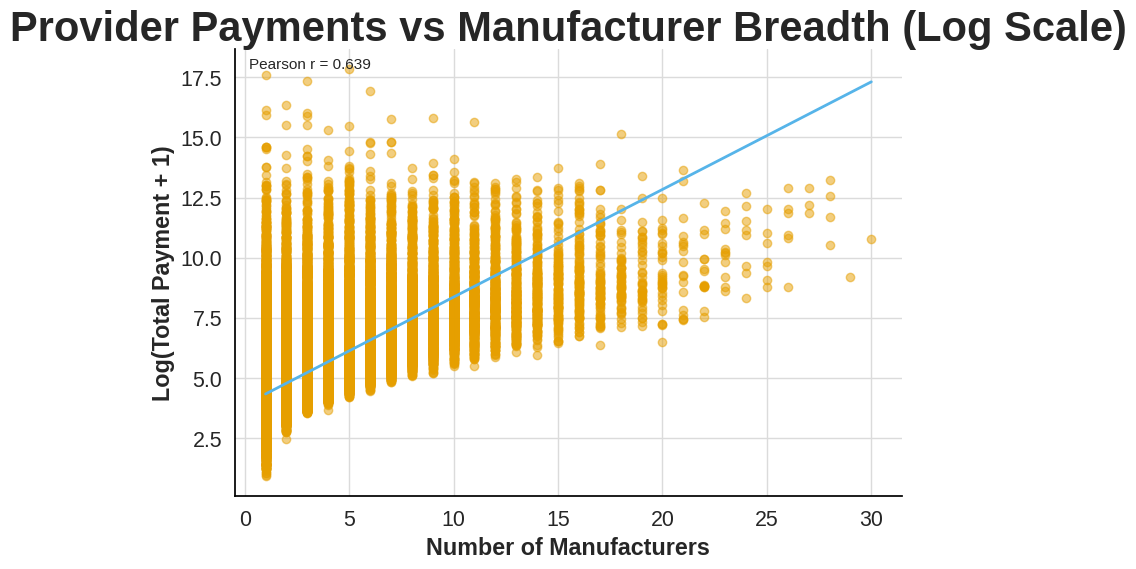

In [18]:
# =============================================================================
# PROVIDER SCATTERPLOT: MANUFACTURER COUNT VS LOG PAYMENTS
# =============================================================================

# Aggregate payments at provider-manufacturer level; removes duplicate rows per pair
provider_mfr = df.groupby(
    ['covered_recipient_npi', 'applicable_manufacturer_or_applicable_gpo_making_payment_name']
)['total_amount_of_payment_us_dollars'].sum().reset_index()

# Rename columns for clarity
provider_mfr.columns = ['npi', 'manufacturer', 'amount']

# Count distinct manufacturers per provider; this becomes the X variable
mfr_counts = provider_mfr.groupby('npi')['manufacturer'].nunique().reset_index()

# Rename column to reflect meaning
mfr_counts.columns = ['npi', 'manufacturer_count']

# Compute total payments per provider; raw payment aggregation
provider_totals = provider_mfr.groupby('npi')['amount'].sum().reset_index()

# Rename column
provider_totals.columns = ['npi', 'total_payment']

# Merge metrics into single provider-level dataset
scatter_df = mfr_counts.merge(provider_totals, on='npi', how='inner')

# Apply log transform using log1p; handles zeros and compresses right tail
scatter_df['log_total_payment'] = np.log1p(scatter_df['total_payment'])

# =============================================================================
# SCATTERPLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Plot providers as individual dots
ax.scatter(
    scatter_df['manufacturer_count'],
    scatter_df['log_total_payment'],
    alpha=0.5,
    color=CB_PALETTE[1]
)

# Axis labels reflect transformed scale
ax.set_xlabel('Number of Manufacturers')
ax.set_ylabel('Log(Total Payment + 1)')

# Title communicates transformation explicitly
ax.set_title('Provider Payments vs Manufacturer Breadth (Log Scale)', fontweight='bold')

# =============================================================================
# RELATIONSHIP ANALYSIS
# =============================================================================

# Pearson correlation on transformed data; reduces outlier dominance
correlation = scatter_df['manufacturer_count'].corr(
    scatter_df['log_total_payment']
)

# Linear regression on transformed outcome
slope, intercept = np.polyfit(
    scatter_df['manufacturer_count'],
    scatter_df['log_total_payment'],
    1
)

# Generate fitted line domain
x_vals = np.linspace(
    scatter_df['manufacturer_count'].min(),
    scatter_df['manufacturer_count'].max(),
    100
)

# Compute regression predictions
y_vals = slope * x_vals + intercept

# Plot regression line
ax.plot(x_vals, y_vals, color=CB_PALETTE[4], linewidth=2)

# Annotate correlation value
ax.text(
    0.02,
    0.98,
    f'Pearson r = {correlation:.3f}',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=11
)

# Prevent clipping
plt.tight_layout()

# Show visualization
plt.show()

######################################
# COMMENTS FOR UPDATING: 
# Color the dots for fraud labeled
######################################

## Research Question 2: Payments and Utilization Indicators

**Question: Are higher manufacturer payments indicative of higher claims reimbursements?**

Note: This dataset contains manufacturer payments, not claims.

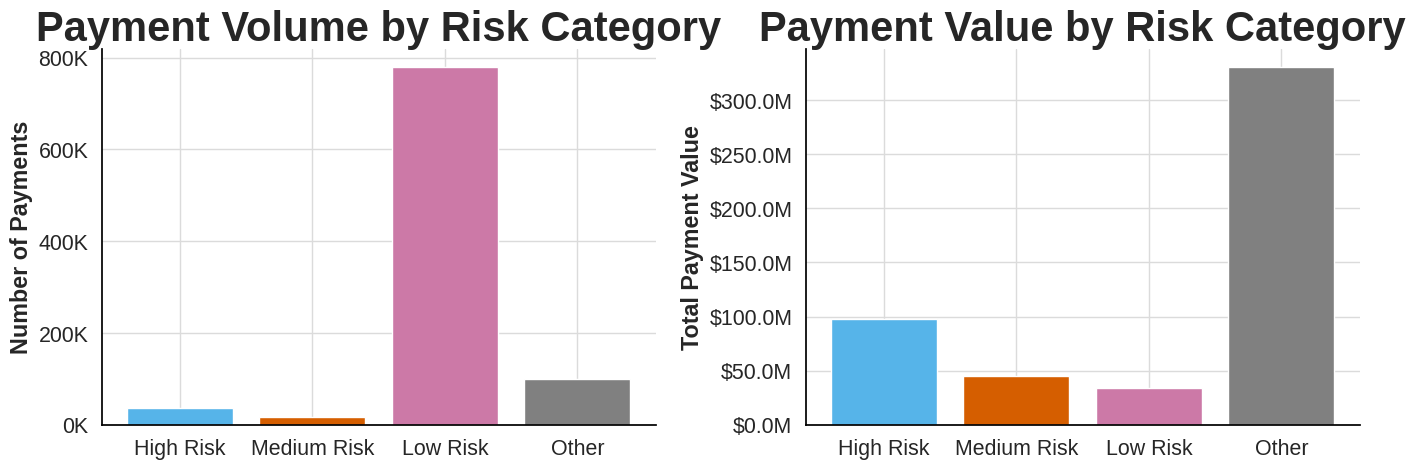

RISK CATEGORY SUMMARY
                count          total     mean   median
risk_category                                         
High Risk       36689  98,056,816.42 2,672.65 1,375.00
Low Risk       780273  33,725,944.19    43.22    21.32
Medium Risk     16023  44,681,340.13 2,788.58   500.00
Other           99923 330,998,012.90 3,312.53   172.00


In [19]:
# =============================================================================
# PAYMENT RISK CATEGORIES
# =============================================================================
high_risk = ['Consulting', 'Other Services', 'Debt Forgiveness']
medium_risk = ['Faculty or Speaker', 'Education', 'Ownership or Investment', 'Acquisition']
low_risk = ['Food and Beverage','Charity', 'Entertainment']

def categorize_risk(nature):
    if nature in high_risk: return 'High Risk'
    elif nature in medium_risk: return 'Medium Risk'
    elif nature in low_risk: return 'Low Risk'
    else: return 'Other'

df['risk_category'] = df['nature_short_descr'].apply(categorize_risk)

risk_summary = df.groupby('risk_category').agg({
    'total_amount_of_payment_us_dollars': ['count', 'sum', 'mean', 'median']
}).round(2)
risk_summary.columns = ['count', 'total', 'mean', 'median']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Payment count by risk
ax1 = axes[0]
risk_order = ['High Risk', 'Medium Risk', 'Low Risk', 'Other']
risk_colors = [CB_PALETTE[4], CB_PALETTE[5], CB_PALETTE[3], 'gray']
counts = [risk_summary.loc[r, 'count'] if r in risk_summary.index else 0 for r in risk_order]
ax1.bar(risk_order, counts, color=risk_colors, edgecolor='white')
ax1.set_ylabel('Number of Payments')
ax1.set_title('Payment Volume by Risk Category', fontweight='bold')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

# Total value by risk
ax2 = axes[1]
totals = [risk_summary.loc[r, 'total'] if r in risk_summary.index else 0 for r in risk_order]
ax2.bar(risk_order, totals, color=risk_colors, edgecolor='white')
ax2.set_ylabel('Total Payment Value')
ax2.set_title('Payment Value by Risk Category', fontweight='bold')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
# plt.savefig('risk_categories.png', dpi=150, bbox_inches='tight')
plt.show()

print('RISK CATEGORY SUMMARY')
print('=' * 70)
print(risk_summary)

######################################
# COMMENTS FOR UPDATING: 
# Fix this to check on "Other Category". This is too high so descrption may need to be updated.
# KEEEEEEP THIS!
######################################

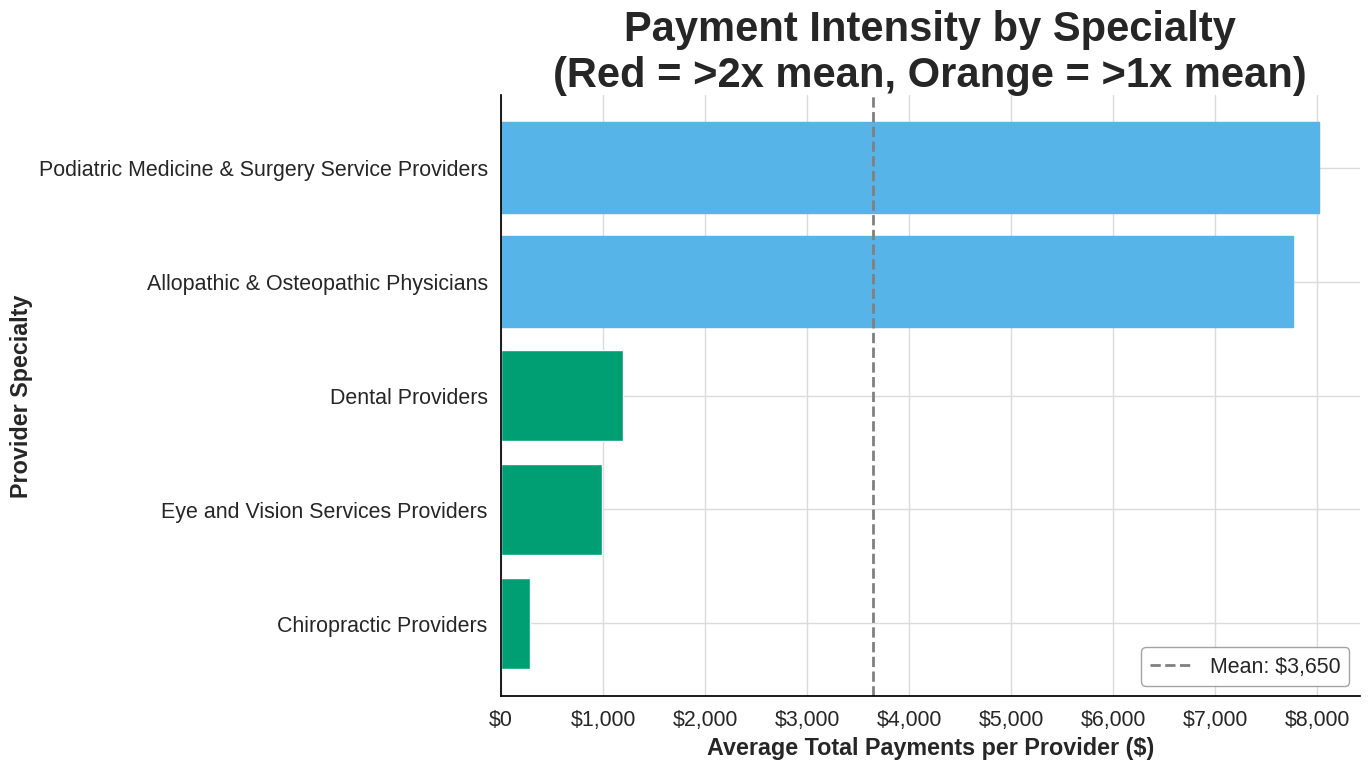

In [20]:
# =============================================================================
# SPECIALTY PAYMENT INTENSITY
# =============================================================================
specialty_intensity = provider_stats.groupby('specialty').agg({
    'npi': 'count',
    'total_received': ['sum', 'mean', 'median'],
    'payment_count': 'mean'
}).reset_index()
specialty_intensity.columns = ['specialty', 'provider_count', 'total_value', 'mean_per_provider', 'median_per_provider', 'avg_payments']
specialty_intensity = specialty_intensity[specialty_intensity['provider_count'] >= 50]
specialty_intensity = specialty_intensity.sort_values('mean_per_provider', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
top_specs = specialty_intensity.head(15)
overall_mean = specialty_intensity['mean_per_provider'].mean()
bars = ax.barh(top_specs['specialty'][::-1], top_specs['mean_per_provider'][::-1], color=CB_PALETTE[2], edgecolor='white')

for bar, val in zip(bars, top_specs['mean_per_provider'][::-1]):
    if val > overall_mean * 2: bar.set_color(CB_PALETTE[4])
    elif val > overall_mean: bar.set_color(CB_PALETTE[5])

ax.axvline(overall_mean, color='gray', linestyle='--', linewidth=2, label=f'Mean: ${overall_mean:,.0f}')
ax.set_xlabel('Average Total Payments per Provider ($)')
ax.set_ylabel('Provider Specialty')
ax.set_title('Payment Intensity by Specialty\n(Red = >2x mean, Orange = >1x mean)', fontweight='bold')
ax.legend(loc='lower right')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
# plt.savefig('specialty_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

######################################
# COMMENTS FOR UPDATING: 
# Maybe add this, consider adding the line and coloring to the box and whisker. 
######################################

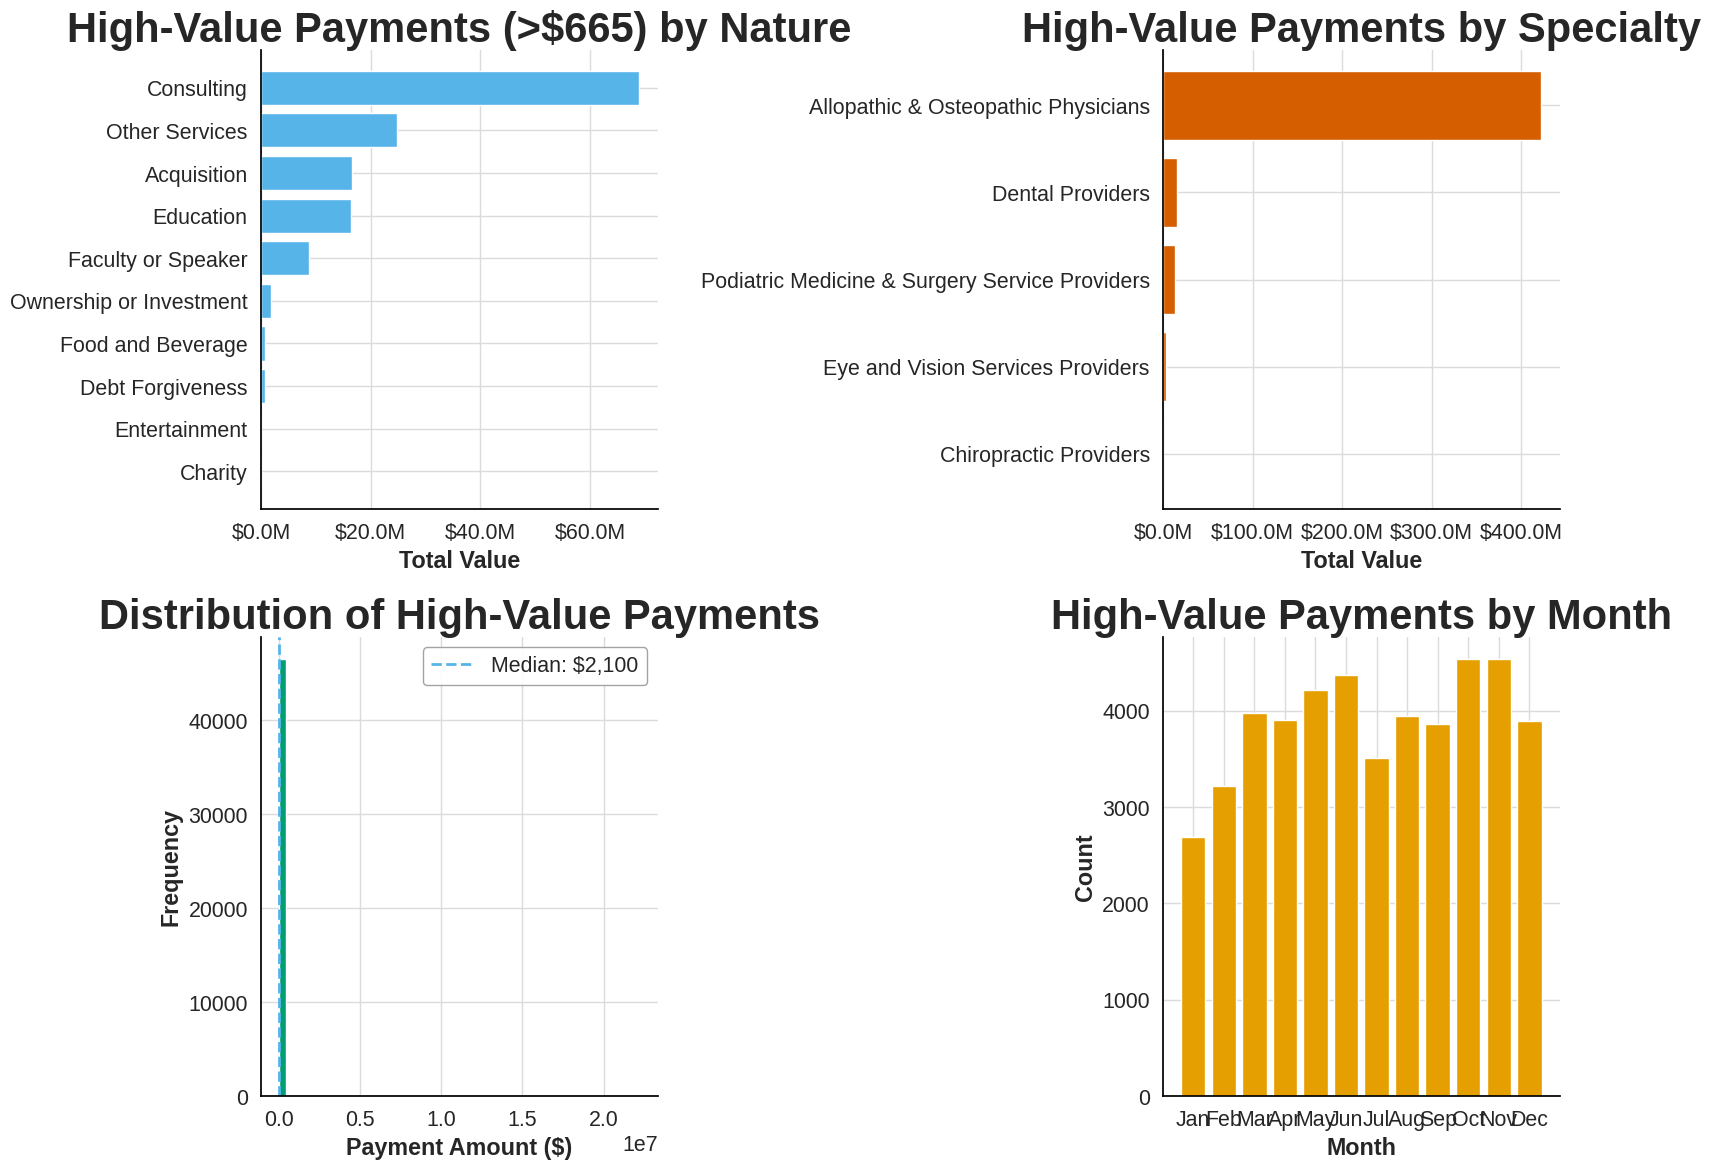

In [21]:
# =============================================================================
# HIGH-VALUE PAYMENT ANALYSIS
# =============================================================================
threshold_95 = df['total_amount_of_payment_us_dollars'].quantile(0.95)
high_value = df[df['total_amount_of_payment_us_dollars'] >= threshold_95].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# By nature
ax1 = axes[0, 0]
hv_nature = high_value.groupby('nature_short_descr')['total_amount_of_payment_us_dollars'].sum().sort_values(ascending=True)
ax1.barh(hv_nature.index, hv_nature.values, color=CB_PALETTE[4], edgecolor='white')
ax1.set_xlabel('Total Value')
ax1.set_title(f'High-Value Payments (>${threshold_95:,.0f}) by Nature', fontweight='bold')
ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# By specialty
ax2 = axes[0, 1]
hv_spec = high_value.groupby('specialty_lvl1')['total_amount_of_payment_us_dollars'].sum().sort_values(ascending=True)
ax2.barh(hv_spec.index, hv_spec.values, color=CB_PALETTE[5], edgecolor='white')
ax2.set_xlabel('Total Value')
ax2.set_title('High-Value Payments by Specialty', fontweight='bold')
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Distribution
ax3 = axes[1, 0]
ax3.hist(high_value['total_amount_of_payment_us_dollars'], bins=50, color=CB_PALETTE[2], edgecolor='white')
ax3.axvline(high_value['total_amount_of_payment_us_dollars'].median(), color=CB_PALETTE[4], linestyle='--', linewidth=2, label=f'Median: ${high_value["total_amount_of_payment_us_dollars"].median():,.0f}')
ax3.set_xlabel('Payment Amount ($)')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of High-Value Payments', fontweight='bold')
ax3.legend()

# Monthly
ax4 = axes[1, 1]
hv_month = high_value.groupby('payment_month').size()
ax4.bar(range(1, 13), hv_month.reindex(range(1, 13), fill_value=0), color=CB_PALETTE[1], edgecolor='white')
ax4.set_xlabel('Month')
ax4.set_ylabel('Count')
ax4.set_title('High-Value Payments by Month', fontweight='bold')
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
# plt.savefig('high_value_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

######################################
# COMMENTS FOR UPDATING: 
# Push the specialty out to the more granular level
# Keep it at the total value
# Maybe break it out to the manufacturer level, number of providers, number of payments
######################################

### Nature of Payments Analysis

In [22]:
# =============================================================================
# NATURE OF PAYMENT SUMMARY
# =============================================================================
nature_summary = df.groupby('nature_short_descr').agg({
    'total_amount_of_payment_us_dollars': ['count', 'sum', 'mean', 'median']
}).round(2)
nature_summary.columns = ['count', 'total_value', 'mean', 'median']
nature_summary = nature_summary.sort_values('total_value', ascending=False)
nature_summary['pct_transactions'] = (nature_summary['count'] / nature_summary['count'].sum() * 100).round(2)
nature_summary['pct_value'] = (nature_summary['total_value'] / nature_summary['total_value'].sum() * 100).round(2)

print('NATURE OF PAYMENT SUMMARY')
print('=' * 100)
print(nature_summary.to_string())

NATURE OF PAYMENT SUMMARY
                          count   total_value       mean    median  pct_transactions  pct_value
nature_short_descr                                                                             
Consulting                25314 71,431,363.55   2,821.81  1,400.00              3.04      40.48
Food and Beverage        779424 33,656,819.31      43.18     21.31             93.57      19.07
Other Services            10922 25,897,673.55   2,371.15  1,459.50              1.31      14.68
Education                 13702 17,312,525.39   1,263.50    272.95              1.64       9.81
Acquisition                 143 16,536,562.72 115,640.30 14,122.07              0.02       9.37
Faculty or Speaker         2167  8,996,138.67   4,151.43  1,800.00              0.26       5.10
Ownership or Investment      11  1,836,113.35 166,919.40  5,866.29              0.00       1.04
Debt Forgiveness            453    727,779.32   1,606.58     49.51              0.05       0.41
Entertainment 

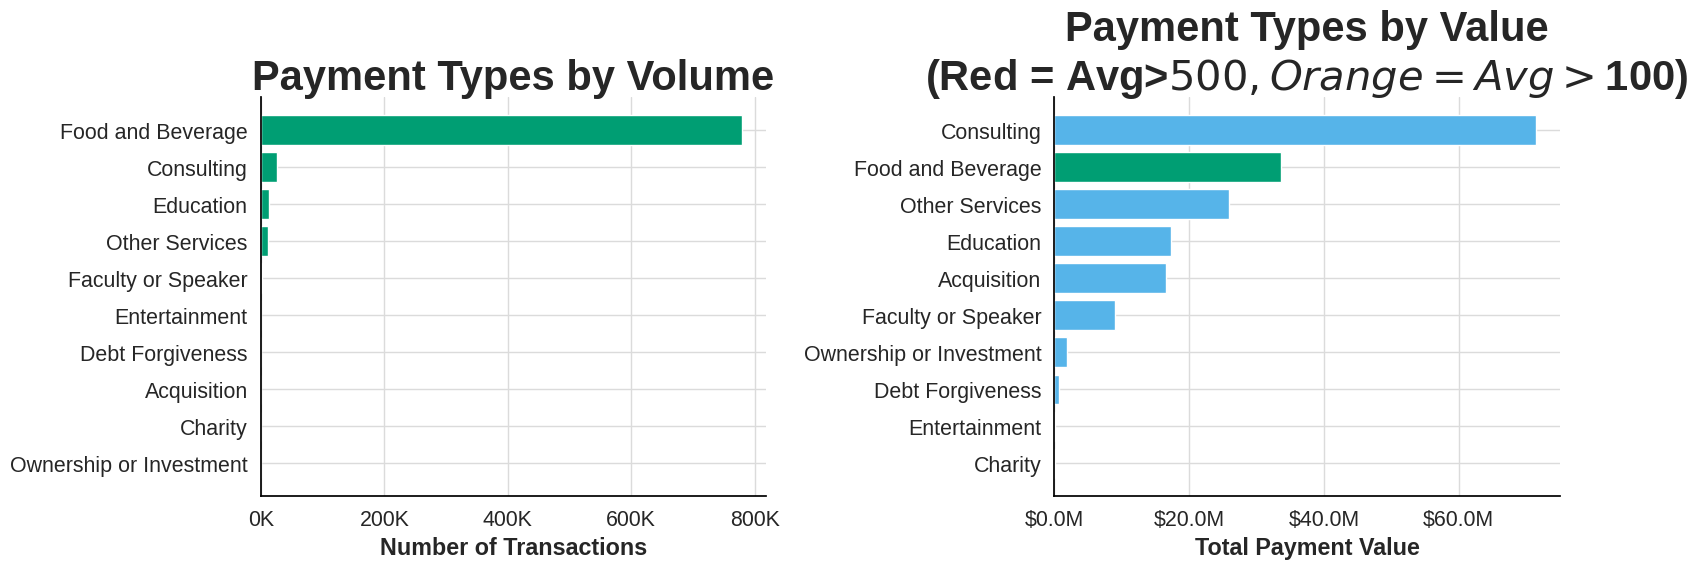

In [23]:
# =============================================================================
# NATURE OF PAYMENT VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Volume
ax1 = axes[0]
ns = nature_summary.sort_values('count', ascending=True)
ax1.barh(ns.index, ns['count'], color=CB_PALETTE[2], edgecolor='white')
ax1.set_xlabel('Number of Transactions')
ax1.set_title('Payment Types by Volume', fontweight='bold')
ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

# Value
ax2 = axes[1]
ns_val = nature_summary.sort_values('total_value', ascending=True)
avg_per = ns_val['total_value'] / ns_val['count']
colors = [CB_PALETTE[4] if x > 500 else CB_PALETTE[5] if x > 100 else CB_PALETTE[2] for x in avg_per]
ax2.barh(ns_val.index, ns_val['total_value'], color=colors, edgecolor='white')
ax2.set_xlabel('Total Payment Value')
ax2.set_title('Payment Types by Value\n(Red = Avg>$500, Orange = Avg>$100)', fontweight='bold')
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
# plt.savefig('nature_overview.png', dpi=150, bbox_inches='tight')
plt.show()

######################################
# COMMENTS FOR UPDATING: 
# REMOVE BOTH
######################################

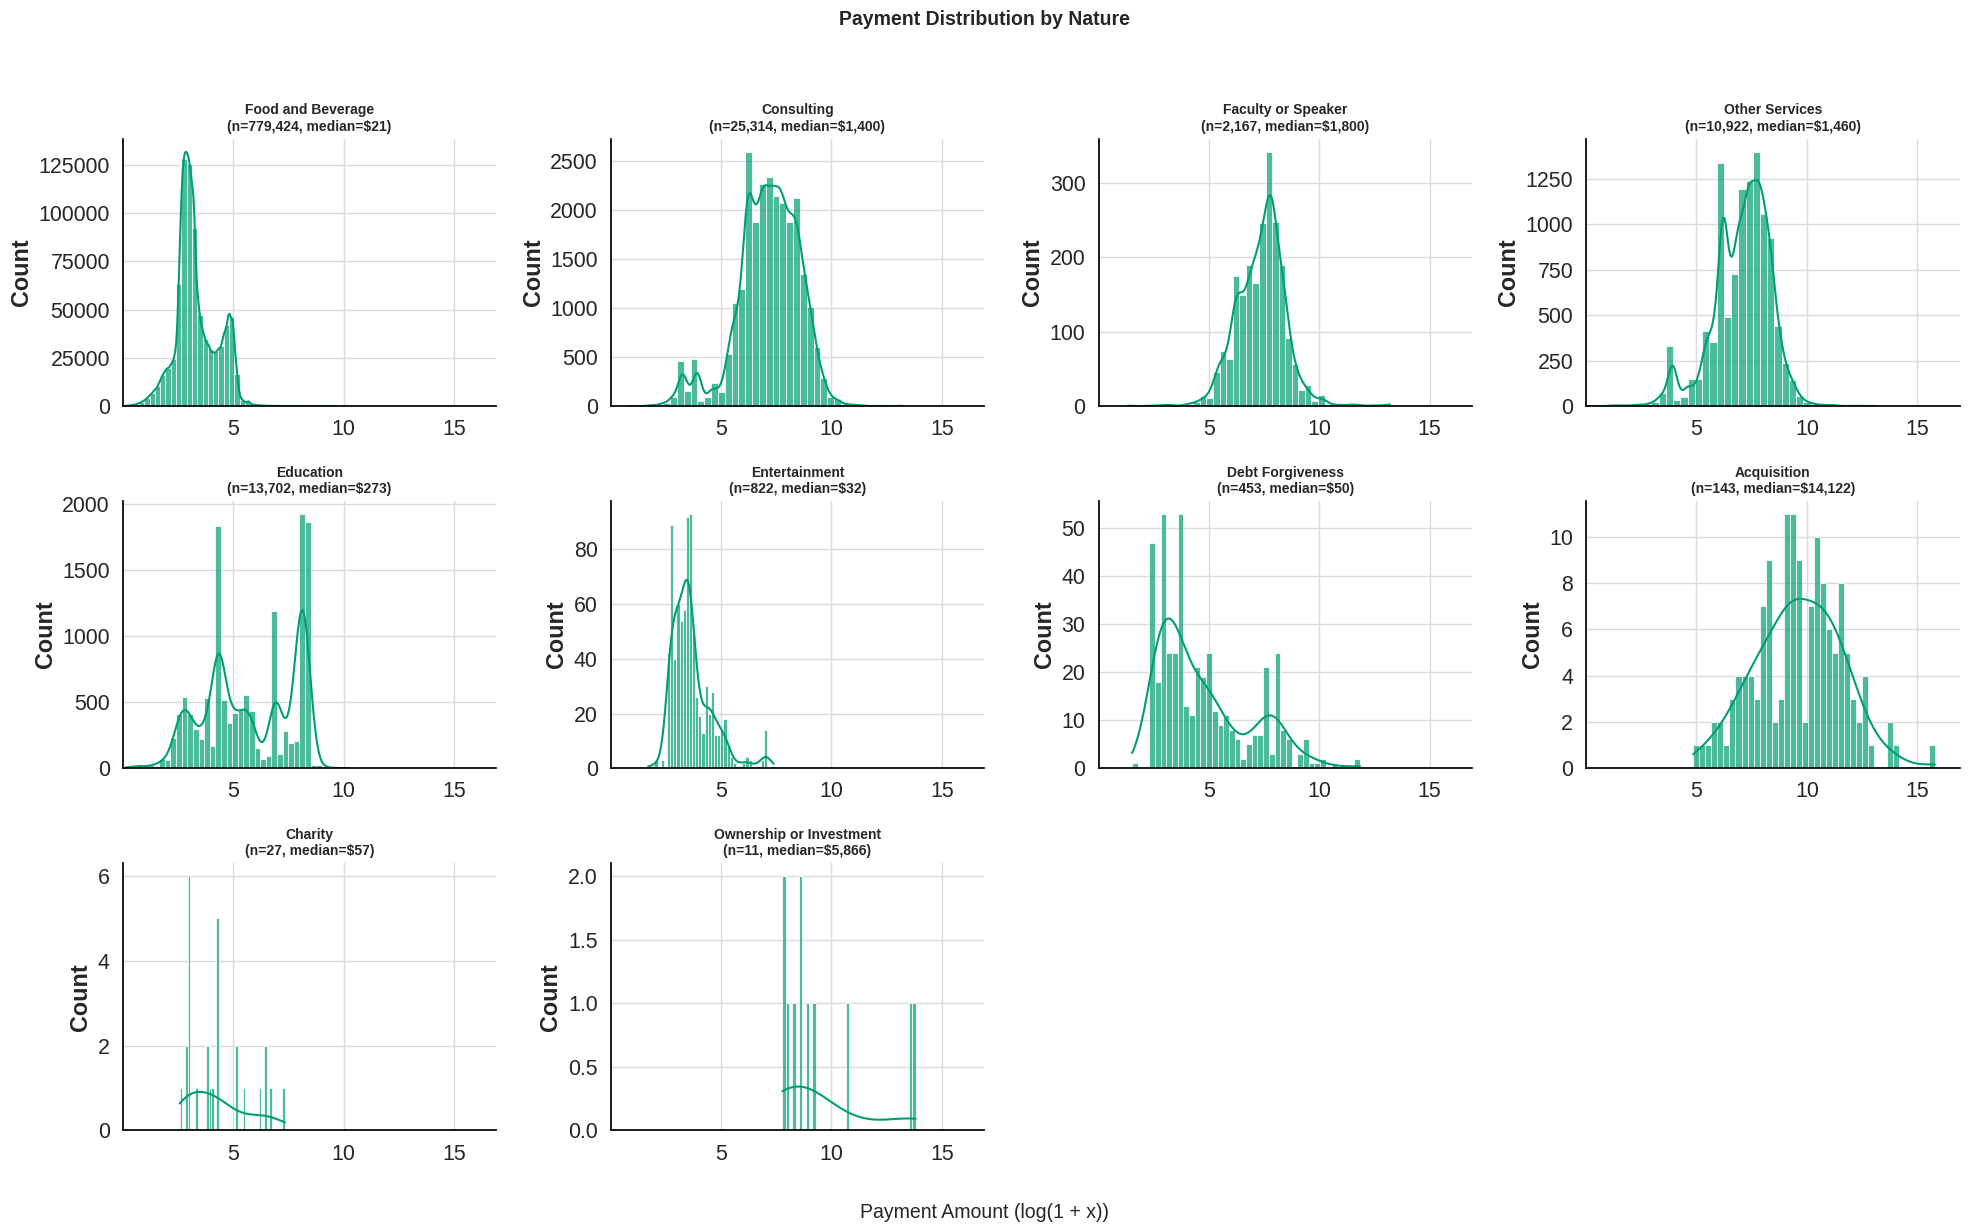

In [24]:
# =============================================================================
# PAYMENT DISTRIBUTIONS BY NATURE
# =============================================================================
natures = df['nature_short_descr'].dropna().unique()
n = len(natures)
cols = 4
rows = int(np.ceil(n / cols))
xmin, xmax = df['log_amount'].min(), df['log_amount'].max()

fig, axes = plt.subplots(rows, cols, figsize=(20, 4*rows))
axes = axes.flatten()

for i, nature in enumerate(natures):
    ax = axes[i]
    subset = df[df['nature_short_descr'] == nature]
    sns.histplot(subset['log_amount'], bins=40, kde=True, ax=ax, color=CB_PALETTE[2], alpha=0.7)
    ax.set_xlim(xmin, xmax)
    ax.set_title(f"{nature}\n(n={len(subset):,}, median=${subset['total_amount_of_payment_us_dollars'].median():,.0f})", fontsize=10)
    ax.set_ylabel('Count')
    ax.set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.supxlabel('Payment Amount (log(1 + x))', fontsize=14)
fig.suptitle('Payment Distribution by Nature', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('nature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Temporal and Geographic Analysis

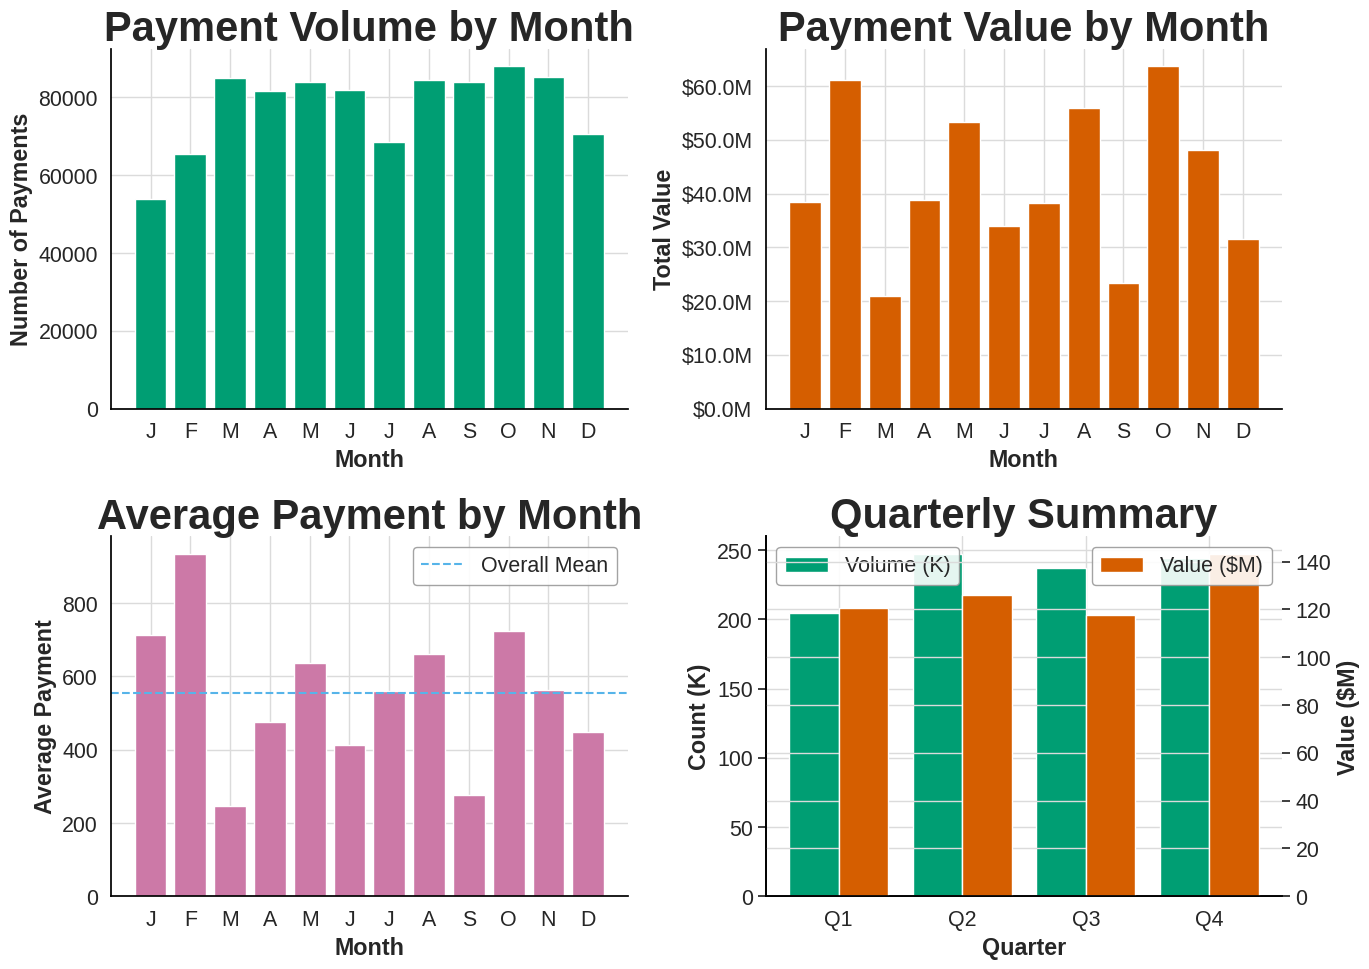

In [25]:
# =============================================================================
# TEMPORAL PATTERNS
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

monthly = df.groupby('payment_month')['total_amount_of_payment_us_dollars'].agg(['count', 'sum', 'mean'])

# Volume by month
ax1 = axes[0, 0]
ax1.bar(range(1, 13), monthly['count'], color=CB_PALETTE[2], edgecolor='white')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Payments')
ax1.set_title('Payment Volume by Month', fontweight='bold')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])

# Value by month
ax2 = axes[0, 1]
ax2.bar(range(1, 13), monthly['sum'], color=CB_PALETTE[5], edgecolor='white')
ax2.set_xlabel('Month')
ax2.set_ylabel('Total Value')
ax2.set_title('Payment Value by Month', fontweight='bold')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Average by month
ax3 = axes[1, 0]
ax3.bar(range(1, 13), monthly['mean'], color=CB_PALETTE[3], edgecolor='white')
ax3.axhline(monthly['mean'].mean(), color=CB_PALETTE[4], linestyle='--', label='Overall Mean')
ax3.set_xlabel('Month')
ax3.set_ylabel('Average Payment')
ax3.set_title('Average Payment by Month', fontweight='bold')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax3.legend()

# Quarterly
ax4 = axes[1, 1]
quarterly = df.groupby('payment_quarter')['total_amount_of_payment_us_dollars'].agg(['count', 'sum'])
x = np.arange(4)
ax4.bar(x - 0.2, quarterly['count']/1000, 0.4, label='Volume (K)', color=CB_PALETTE[2])
ax4b = ax4.twinx()
ax4b.bar(x + 0.2, quarterly['sum']/1e6, 0.4, label='Value ($M)', color=CB_PALETTE[5])
ax4.set_xlabel('Quarter')
ax4.set_ylabel('Count (K)')
ax4b.set_ylabel('Value ($M)')
ax4.set_title('Quarterly Summary', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax4.legend(loc='upper left')
ax4b.legend(loc='upper right')

plt.tight_layout()
# plt.savefig('temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

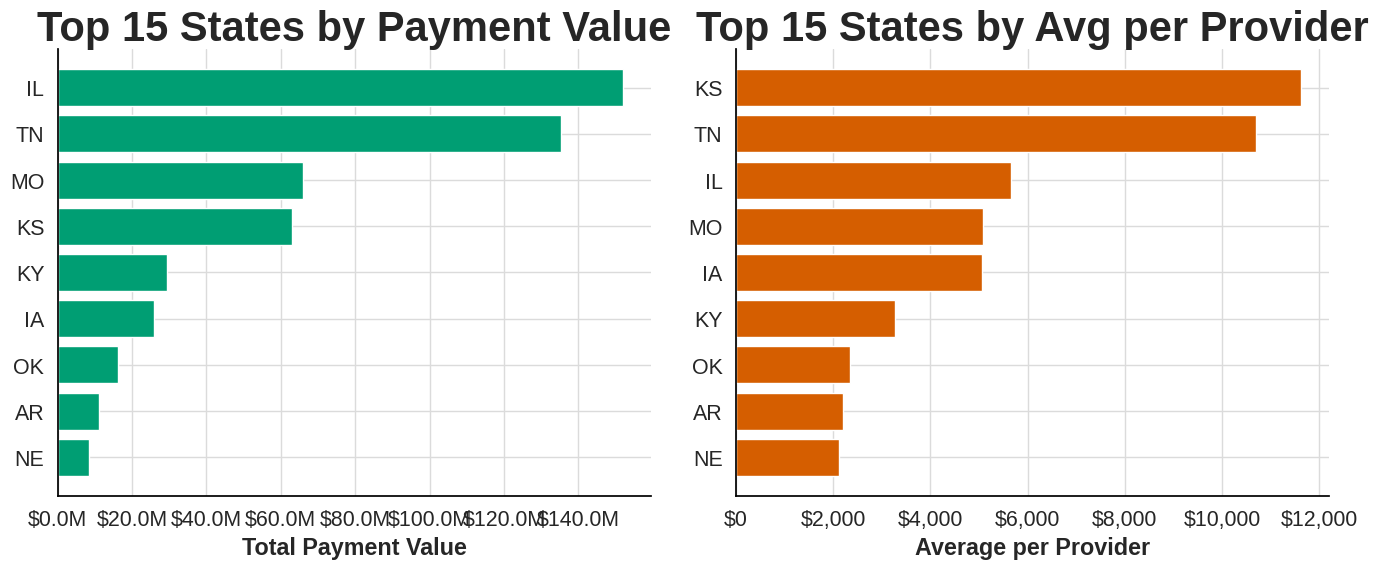

In [26]:
# =============================================================================
# GEOGRAPHIC ANALYSIS
# =============================================================================
state_stats = df.groupby('recipient_state').agg({
    'total_amount_of_payment_us_dollars': ['count', 'sum', 'mean'],
    'covered_recipient_npi': 'nunique'
}).round(2)
state_stats.columns = ['count', 'total', 'mean', 'providers']
state_stats['per_provider'] = state_stats['total'] / state_stats['providers']
state_stats = state_stats.sort_values('total', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Total by state
ax1 = axes[0]
top_states = state_stats.head(15)
ax1.barh(top_states.index[::-1], top_states['total'][::-1], color=CB_PALETTE[2], edgecolor='white')
ax1.set_xlabel('Total Payment Value')
ax1.set_title('Top 15 States by Payment Value', fontweight='bold')
ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Per provider by state
ax2 = axes[1]
sig_states = state_stats[state_stats['providers'] >= 100].nlargest(15, 'per_provider')
ax2.barh(sig_states.index[::-1], sig_states['per_provider'][::-1], color=CB_PALETTE[5], edgecolor='white')
ax2.set_xlabel('Average per Provider')
ax2.set_title('Top 15 States by Avg per Provider', fontweight='bold')
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
# plt.savefig('geographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

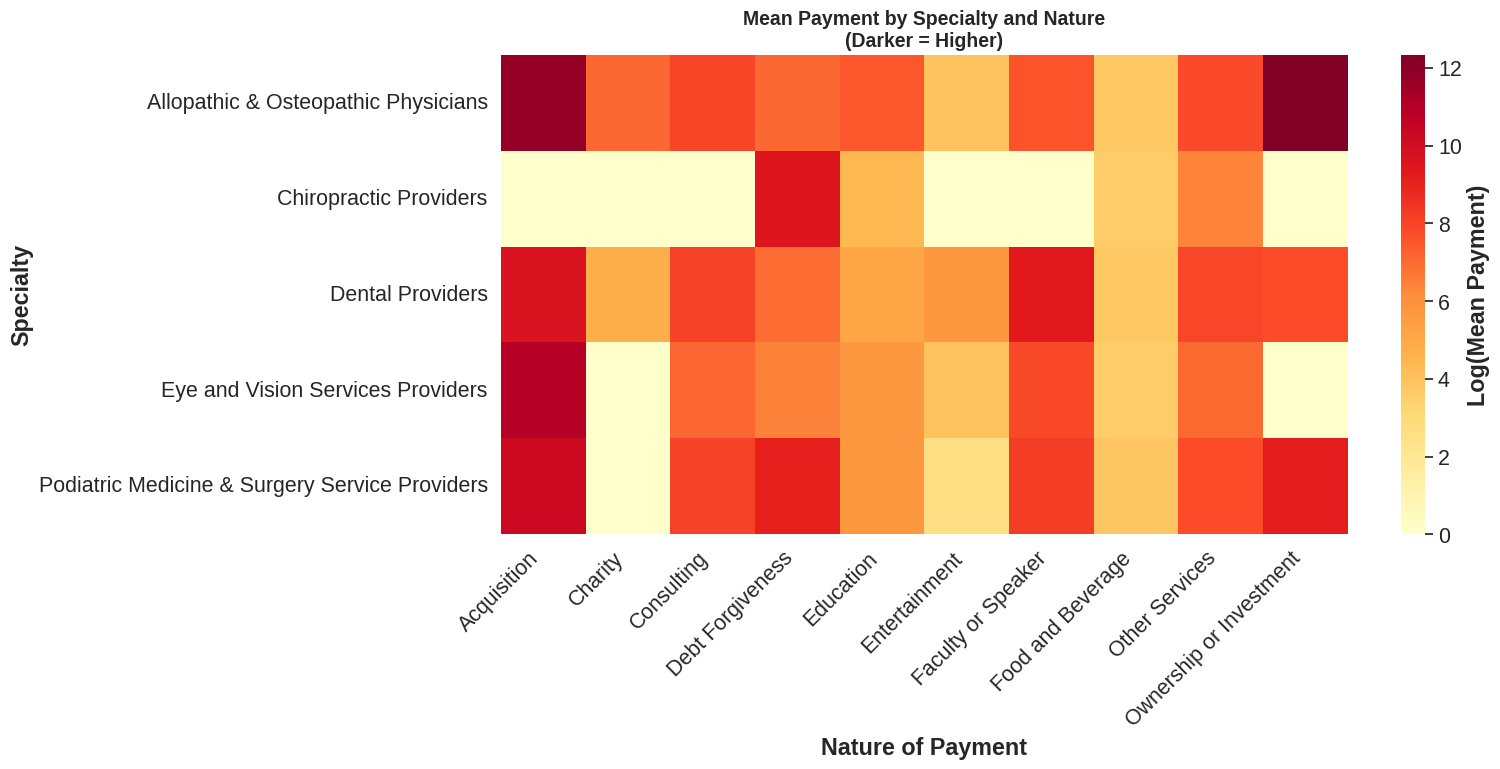

In [27]:
# =============================================================================
# SPECIALTY x NATURE HEATMAP
# =============================================================================
pivot = df.pivot_table(values='total_amount_of_payment_us_dollars', index='specialty_lvl1', columns='nature_short_descr', aggfunc='mean').fillna(0)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(np.log1p(pivot), annot=False, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Log(Mean Payment)'})
ax.set_title('Mean Payment by Specialty and Nature\n(Darker = Higher)', fontweight='bold', fontsize=14)
ax.set_xlabel('Nature of Payment')
ax.set_ylabel('Specialty')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('specialty_nature_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Investigation Summary

In [29]:
# =============================================================================
# INVESTIGATION SUMMARY
# =============================================================================
print('=' * 90)
print('FRAUD INVESTIGATION SUMMARY')
print('=' * 90)

print('\nDATASET OVERVIEW')
print(f'   Total records: {len(df):,}')
print(f'   Total value: ${df["total_amount_of_payment_us_dollars"].sum():,.2f}')
print(f'   Unique providers: {unique_providers:,}')
print(f'   Unique manufacturers: {unique_manufacturers:,}')

print('\n' + '-' * 90)
print('RESEARCH QUESTION 1: PROVIDER OUTLIERS')
print('-' * 90)
print(f'   Outlier providers (z>3): {provider_stats["is_outlier_any"].sum():,}')
print('\n' + '-' * 90)
print('RESEARCH QUESTION 2: PAYMENT-UTILIZATION INDICATORS')
print('-' * 90)
if 'High Risk' in risk_summary.index:
    print(f'   High-risk payments: {risk_summary.loc["High Risk", "count"]:,.0f} (${risk_summary.loc["High Risk", "total"]:,.2f})')
print(f'   High-value payments (top 5%): {len(high_value):,}')

FRAUD INVESTIGATION SUMMARY

DATASET OVERVIEW
   Total records: 932,908
   Total value: $507,462,113.64
   Unique providers: 85,287
   Unique manufacturers: 836

------------------------------------------------------------------------------------------
RESEARCH QUESTION 1: PROVIDER OUTLIERS
------------------------------------------------------------------------------------------
   Outlier providers (z>3): 1,281

------------------------------------------------------------------------------------------
RESEARCH QUESTION 2: PAYMENT-UTILIZATION INDICATORS
------------------------------------------------------------------------------------------
   High-risk payments: 36,689 ($98,056,816.42)
   High-value payments (top 5%): 46,649


In [30]:
# =============================================================================
# EXPORT FLAGGED PROVIDERS
# =============================================================================
export_df = provider_stats.copy()
export_df['risk_flags'] = ''
export_df.loc[export_df['is_outlier_total'], 'risk_flags'] += 'HIGH_TOTAL|'
export_df.loc[export_df['is_outlier_count'], 'risk_flags'] += 'HIGH_COUNT|'
export_df.loc[export_df['total_received'] >= top_1pct_threshold, 'risk_flags'] += 'TOP_1PCT|'

flagged = export_df[export_df['risk_flags'] != ''].sort_values('total_received', ascending=False)

print(f'Flagged providers for investigation: {len(flagged):,}')
print(f'Total value: ${flagged["total_received"].sum():,.2f}')

cols = ['npi', 'specialty', 'state', 'payment_count', 'total_received', 'mean_payment', 'num_manufacturers','risk_flags']
# flagged[cols].to_csv('flagged_providers.csv', index=False)

Flagged providers for investigation: 1,281
Total value: $432,400,566.77
